In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense ,GlobalAveragePooling2D ,Dropout 
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
train_generator = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode="nearest"
)

test_generator = ImageDataGenerator( rescale=1.0/255 )

train = train_generator.flow_from_directory(
    'archive/train',
    target_size=(128,128),
    batch_size=32,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True )

test = test_generator.flow_from_directory( 
    'archive/test',
    target_size=(128,128),
    batch_size=32,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False )

val = test_generator.flow_from_directory(
    'archive/validation',
    target_size=(128,128),
    batch_size=32,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True )

Found 3115 images belonging to 36 classes.
Found 359 images belonging to 36 classes.
Found 351 images belonging to 36 classes.


In [3]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False  

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),
    Dropout(0.25),
    
    Dense(128, activation='relu'),
    Dropout(0.3),
    
    Dense(256, activation='relu'),
    Dropout(0.4),
    
    Dense(train.num_classes, activation='softmax')  
])
model.summary()

I0000 00:00:1757749924.963868   63307 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4146 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2025-09-13 11:22:05.115376: W external/local_xla/xla/service/gpu/llvm_gpu_backend/default/nvptx_libdevice_path.cc:41] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykernel_launcher.runfiles/cuda_nvdisasm
  ipykernel_launcher.runfiles/nvidia_nvshmem
  ipykern/cuda_nvcc
  ipykern/cuda_nvdisasm
  ipykern/nvidia_nvshmem
  
  /usr/local/cuda
  /opt/cuda
  /home/yash/anaconda3/lib/python3.13/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/yash/anaconda3/lib/python3.13/site-packages/tensorflow/py

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,390,564 (9.12 MB)

 Trainable params: 132,580 (517.89 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
model.compile(
    'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
history = model.fit(
    train,
    validation_data=val,
    epochs=100
)

/home/yash/anaconda3/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/home/yash/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/100


2025-09-13 11:22:11.419921: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d6d18015240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-13 11:22:11.419961: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-09-13 11:22:11.471139: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-13 11:22:11.899474: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-09-13 11:22:12.054196: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-09-13 11:22:12.

27/98 ━━━━━━━━━━━━━━━━━━━━ 42s 605ms/step - accuracy: 0.0368 - loss: 3.6585

2025-09-13 11:22:40.946998: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5223', 8 bytes spill stores, 8 bytes spill loads

2025-09-13 11:22:46.117493: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-09-13 11:22:46.202507: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.0615 - loss: 3.5381  

2025-09-13 11:23:36.605611: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-09-13 11:23:36.605641: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-09-13 11:23:37.060081: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1192', 16 bytes spill stores, 16 bytes spill loads

2025-09-13 11:23:37.101700: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning :

98/98 ━━━━━━━━━━━━━━━━━━━━ 105s 940ms/step - accuracy: 0.1136 - loss: 3.3222 - val_accuracy: 0.4929 - val_loss: 2.1882
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 72s 741ms/step - accuracy: 0.3631 - loss: 2.1959 - val_accuracy: 0.6838 - val_loss: 1.1075
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 72s 733ms/step - accuracy: 0.4909 - loss: 1.6992 - val_accuracy: 0.7151 - val_loss: 0.8670
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 73s 740ms/step - accuracy: 0.5541 - loss: 1.4611 - val_accuracy: 0.8348 - val_loss: 0.6144
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 72s 729ms/step - accuracy: 0.5778 - loss: 1.3193 - val_accuracy: 0.7949 - val_loss: 0.5883
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 715ms/step - accuracy: 0.6164 - loss: 1.2086 - val_accuracy: 0.8405 - val_loss: 0.5361
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 720ms/step - accuracy: 0.6385 - loss: 1.1381 - val_accuracy: 0.8519 - val_loss: 0.5090
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 716ms/step - accuracy: 0.6726 - loss: 1.0259 - val_accurac

In [6]:
model.evaluate(test)

/home/yash/anaconda3/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.8921 - loss: 0.2621

2025-09-13 13:30:14.444544: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-09-13 13:30:14.528766: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9331 - loss: 0.1713  


[0.17133229970932007, 0.9331476092338562]

In [8]:
model.save('fruit_model.keras')

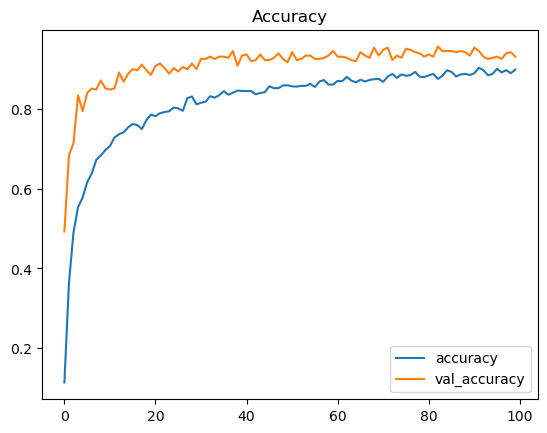

In [20]:
pd.DataFrame(model.history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()